In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [117]:
#-------------------------------------------
# Geometrical Constants
#-------------------------------------------

Rout = 12.0 #outer radius in mm
Rin =  2/3*Rout
L0 = 9 #max height in mm
h = 3 #step height in mm
cl  = 6.7*1e6 #longitudinal wave speed in mm/s
ct  = 5.4*1e6 #transverse wave speed in mm/s
eps = 1e-8
m   = 0

In [118]:
G = 3
k = 1

In [154]:
def step(r):
    return L0 - h * 0.5 * (1 + np.tanh((r - Rin)/eps))

def pc(r):
    return L0-h*(r/Rout)**2

def multistep(r):
    beta = 0
    alpha = 0
    temp = 0
    for i in np.linspace(1,G,G):
        alpha += i**2 * np.tanh((Rout*(0 - (i/G)**k))/eps) 
        beta += i**2 * np.tanh((Rout*(1 - (i/G)**k))/eps)
    d1 = h/(beta- alpha) 
    A = alpha*d1 + L0
    for i in np.linspace(1,G,G):
        temp += i**2 * np.tanh((r - Rout*(i/G)**k)/eps)
    return A - d1*temp

In [155]:
delta = 0.74

In [156]:
Nr = 1000
rho = np.linspace(1e-4, 2, Nr)#(np.arange(Nr) + 0.5)/Nr
mask = rho < 1.0      
drho = rho[1] - rho[0]

In [157]:
rp = rho + drho/2
rm = rho - drho/2

main = (rp + rm)/(rho*drho**2)
upper = -rp/(rho*drho**2)
lower = -rm/(rho*drho**2)

main[0] = 2/drho**2
upper[0] = -2/drho**2
lower[0] = 0

main[-1] = 2/drho**2
lower[-1] = -2/drho**2
upper[-1] = 0

D = sp.diags(
    diagonals=[lower[1:], main, upper[:-1]],
    offsets=[-1, 0, 1],
    format="csr"
)

In [158]:
def Confinement_ratio(psi, rho, rho_in):
    mask = rho < 1.0     
    rho_cut = rho[mask]
    psi_cut = psi[mask]
    density = np.abs(psi_cut)**2 * rho_cut
    I_tot = np.trapezoid(density, rho_cut)
    I_in  = np.trapezoid(density[rho_cut < rho_in],rho_cut[rho_cut < rho_in])
    return I_in / I_tot

def Loss(psi, rho):
    density = np.abs(psi)**2 * rho
    I_tot = np.trapezoid(density, rho)
    I_out  = np.trapezoid(density[rho > 1], rho[rho > 1])
    return I_out / I_tot

def HWHM(psi, rho):
    mask = rho < 1.0      
    rho_cut = rho[mask]
    psi_cut = psi[mask]
    psi = np.abs(np.asarray(psi))
    psi0 = psi[0]
    half = 0.5 * psi0

    idx = np.where(psi <= half)[0]

    if len(idx) == 0:
        raise ValueError("Half maximum non raggiunto nel dominio.")

    i = idx[0] - 1

    rho1, rho2 = rho[i], rho[i+1]
    psi1, psi2 = psi[i], psi[i+1]

    rho_half = rho1 + (half - psi1) * (rho2 - rho1) / (psi2 - psi1)

    return rho_half * Rout

In [159]:
results_step = {
    "N": [1,3,5,7,9,11,13],
    "eigvecs": [],
    "eigvals": [],
    "omegas" : [],
    "CR" : [],
    "Loss" : [],
    "HWHM" : []
}

results_pc = {
    "N": [1,3,5,7,9,11,13],
    "eigvecs": [],
    "eigvals": [],
    "omegas" : [],
    "CR" : [],
    "Loss" : [],
    "HWHM" : []
}

results_ms = {
    "N": [1,3,5,7,9,11,13],
    "eigvecs": [],
    "eigvals": [],
    "omegas" : [],
    "CR" : [],
    "Loss" : [],
    "HWHM" : []
}

In [160]:
R0 = Rout

def ell(rho):
    r = R0*rho
    return multistep(r)/R0

In [161]:
for n in results_step["N"]:

    V = m**2/rho**2 + (cl/ct)**2*(n*np.pi/ell(rho))**2
    A = D + sp.diags(V, 0)

    eigvals, eigvecs = spla.eigs(
        A,
        k=2,
        which="SM"
    )

    eigvals = np.real(eigvals)
    idx = np.argsort(eigvals)

    results_ms["eigvals"].append(eigvals[idx])
    results_ms["eigvecs"].append(eigvecs[:, idx])
    results_ms["omegas"].append(np.sqrt(np.real(eigvals)))
    results_ms["CR"].append(Confinement_ratio(eigvecs[:, 0], rho, Rin/Rout))
    results_ms["Loss"].append(Loss(eigvecs[:, 0], rho))
    results_ms["HWHM"].append(HWHM(eigvecs[:, 0], rho))

In [162]:
R0 = Rout

def ell(rho):
    r = R0*rho
    return step(r)/R0

In [163]:
for n in results_step["N"]:

    V = m**2/rho**2 + (cl/ct)**2*(n*np.pi/ell(rho))**2
    A = D + sp.diags(V, 0)

    eigvals, eigvecs = spla.eigs(
        A,
        k=2,
        which="SM"
    )

    eigvals = np.real(eigvals)
    idx = np.argsort(eigvals)

    results_step["eigvals"].append(eigvals[idx])
    results_step["eigvecs"].append(eigvecs[:, idx])
    results_step["omegas"].append(np.sqrt(np.real(eigvals)))
    results_step["CR"].append(Confinement_ratio(eigvecs[:, 0], rho, Rin/Rout))
    results_step["Loss"].append(Loss(eigvecs[:, 0], rho))
    results_step["HWHM"].append(HWHM(eigvecs[:, 0], rho))

In [164]:
def ell(rho):
    r = R0*rho
    return pc(r)/R0

In [165]:
for n in results_pc["N"]:

    V = m**2/rho**2 + (cl/ct)**2*(n*np.pi/ell(rho))**2
    A = D + sp.diags(V, 0)

    eigvals, eigvecs = spla.eigs(
        A,
        k=2,
        which="SM"
    )

    eigvals = np.real(eigvals)
    idx = np.argsort(eigvals)

    results_pc["eigvals"].append(eigvals[idx])
    results_pc["eigvecs"].append(eigvecs[:, idx])
    results_pc["omegas"].append(np.sqrt(np.real(eigvals)))
    results_pc["CR"].append(Confinement_ratio(eigvecs[:, 0], rho, Rin/Rout))
    results_pc["Loss"].append(Loss(eigvecs[:, 0], rho))
    results_pc["HWHM"].append(HWHM(eigvecs[:, 0], rho))

In [166]:
def normalize_cyl(psi, rho):
    norm = np.trapezoid(psi**2 * rho, rho)
    return psi / np.sqrt(norm)

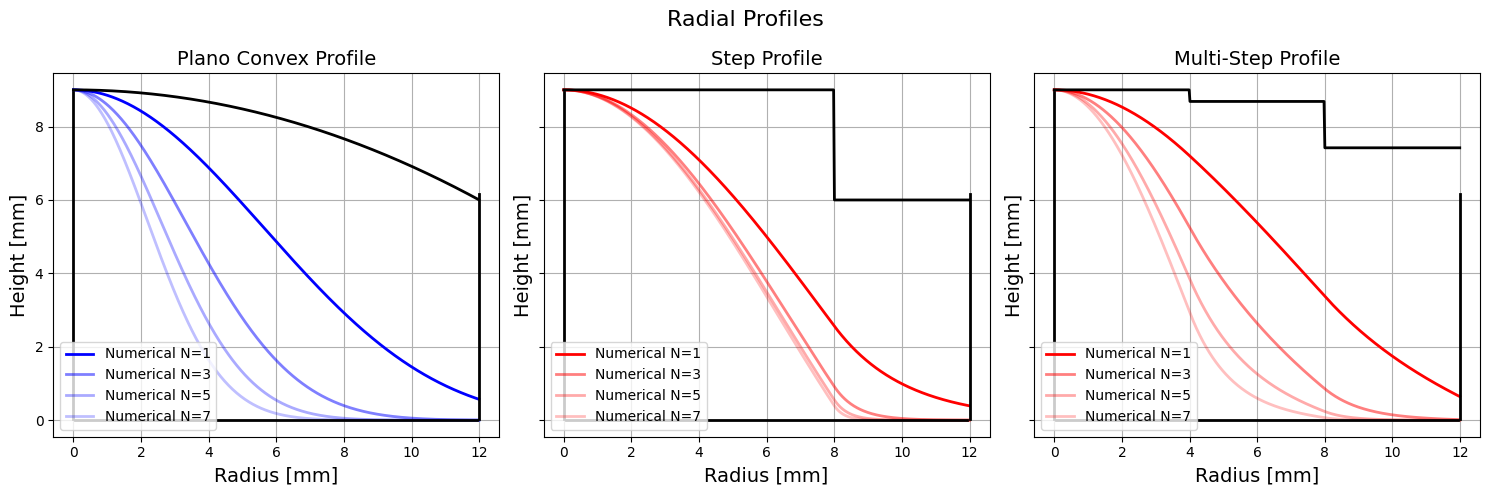

In [167]:
fig, axs = plt.subplots(1, 3, figsize=(15,5), sharey=True)
rho_c = rho[mask] * Rout

for i, n in enumerate([1,3,5,7]):

    psi_pc = normalize_cyl(results_pc["eigvecs"][i][:,0][mask], rho_c)
    psi_pc *= pc(0) / psi_pc[0]
    axs[0].plot(rho_c, np.abs(psi_pc), lw=2, color='b',
                alpha=1/(i+1), label=f'Numerical N={n}')

    psi_step = normalize_cyl(results_step["eigvecs"][i][:,0][mask], rho_c)
    psi_step *= step(0) / psi_step[0]
    axs[1].plot(rho_c, np.abs(psi_step), lw=2, color='r',
                alpha=1/(i+1), label=f'Numerical N={n}')

    psi_ms = normalize_cyl(results_ms["eigvecs"][i][:,0][mask], rho_c)
    psi_ms *= multistep(0) / psi_ms[0]
    axs[2].plot(rho_c, np.abs(psi_ms), lw=2, color='r',
                alpha=1/(i+1), label=f'Numerical N={n}')


axs[0].plot(rho[mask]*Rout, pc(rho[mask]*Rout), color='k', lw=2)
axs[1].plot(rho[mask]*Rout, step(rho[mask]*Rout), color='k', lw=2)
axs[2].plot(rho[mask]*Rout, multistep(rho[mask]*Rout), color='k', lw=2)
axs[0].set_title('Plano Convex Profile', fontsize=14)
axs[1].set_title('Step Profile', fontsize=14)
axs[2].set_title('Multi-Step Profile', fontsize=14)

for i in range(3):
    axs[i].axvline(0, 0.05, 0.95, color='k', lw=2, ls='-')
    axs[i].axhline(0, 0.05, 0.95, color='k', lw=2)
    axs[i].axvline(Rout, 0.05, (L0-h)/L0, color='k', lw=2, ls='-')
    axs[i].set_xlabel('Radius [mm]', fontsize=14)
    axs[i].set_ylabel(r"Height [mm]", fontsize=14)
    axs[i].legend(loc='lower left')
    axs[i].grid()

fig.suptitle('Radial Profiles', fontsize=16)
plt.tight_layout()

In [168]:
def CR_fitter(x,a,b,c,d):
    return a/(np.exp(-c*(x-b))+1) + d

def Loss_fitter(x,b,c,d):
    return np.exp(-b*(x-c))+d

In [169]:
popt_step, _ = curve_fit(CR_fitter, results_step["N"], results_step["CR"], maxfev=10000) 
#popt_pc, _   = curve_fit(CR_fitter, results_pc["N"], results_pc["CR"], maxfev=10000) 
popt_ms, _   = curve_fit(CR_fitter, results_ms["N"], results_ms["CR"], maxfev=10000) 

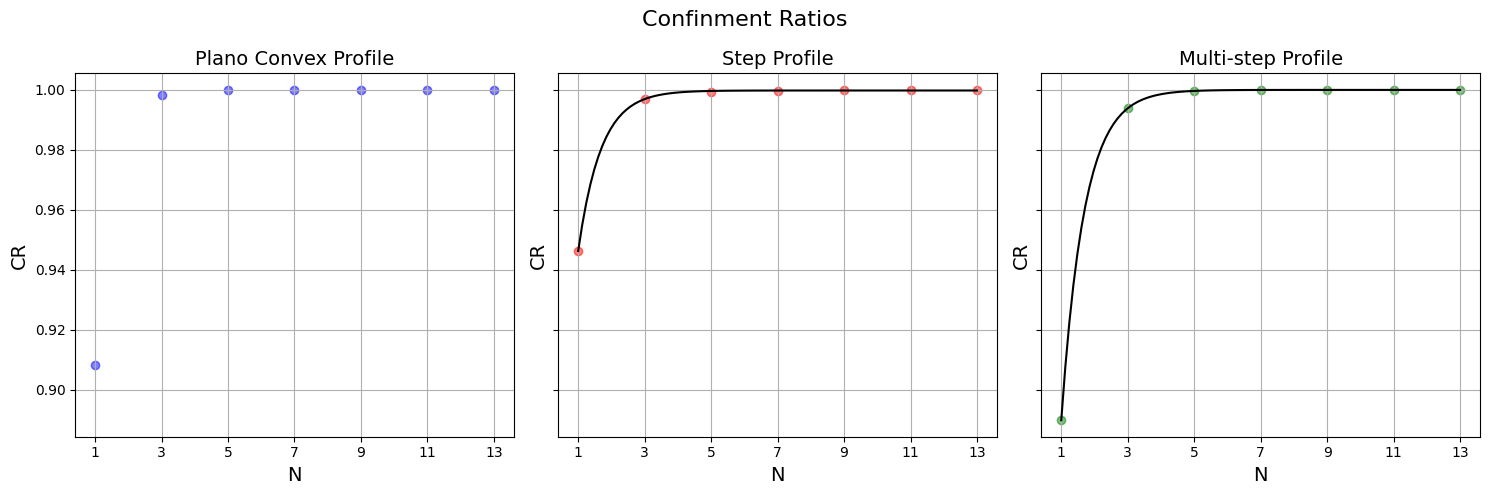

In [170]:
fig, axs = plt.subplots(1, 3, figsize=(15,5), sharey=True)
N_plot = np.linspace(1,13,100)

axs[0].scatter(results_pc["N"], results_pc["CR"],marker='o', color='b', alpha=0.5)
#axs[0].plot(N_plot, CR_fitter(N_plot, *popt_pc), color='k', label='fit')
axs[0].set_title('Plano Convex Profile', fontsize=14)

axs[1].scatter(results_step["N"], results_step["CR"], marker='o', color='r', alpha=0.5)
axs[1].plot(N_plot, CR_fitter(N_plot, *popt_step), color='k', label='fit')
axs[1].set_title('Step Profile', fontsize=14)

axs[2].scatter(results_ms["N"], results_ms["CR"], marker='o', color='g', alpha=0.5)
axs[2].plot(N_plot, CR_fitter(N_plot, *popt_ms), color='k', label='fit')
axs[2].set_title('Multi-step Profile', fontsize=14)

for i in range(3):
    axs[i].set_xlabel('N', fontsize=14)
    axs[i].set_xticks(results_pc["N"])
    axs[i].set_ylabel(r"CR", fontsize=14)
    axs[i].grid()

fig.suptitle('Confinment Ratios', fontsize=16)
plt.tight_layout()

In [171]:
popt_loss_step, _ = curve_fit(Loss_fitter, results_step["N"], results_step["Loss"], maxfev=10000) 
popt_loss_pc, _   = curve_fit(Loss_fitter, results_pc["N"], results_pc["Loss"], maxfev=10000) 
popt_loss_ms, _   = curve_fit(Loss_fitter, results_ms["N"], results_ms["Loss"], maxfev=10000)

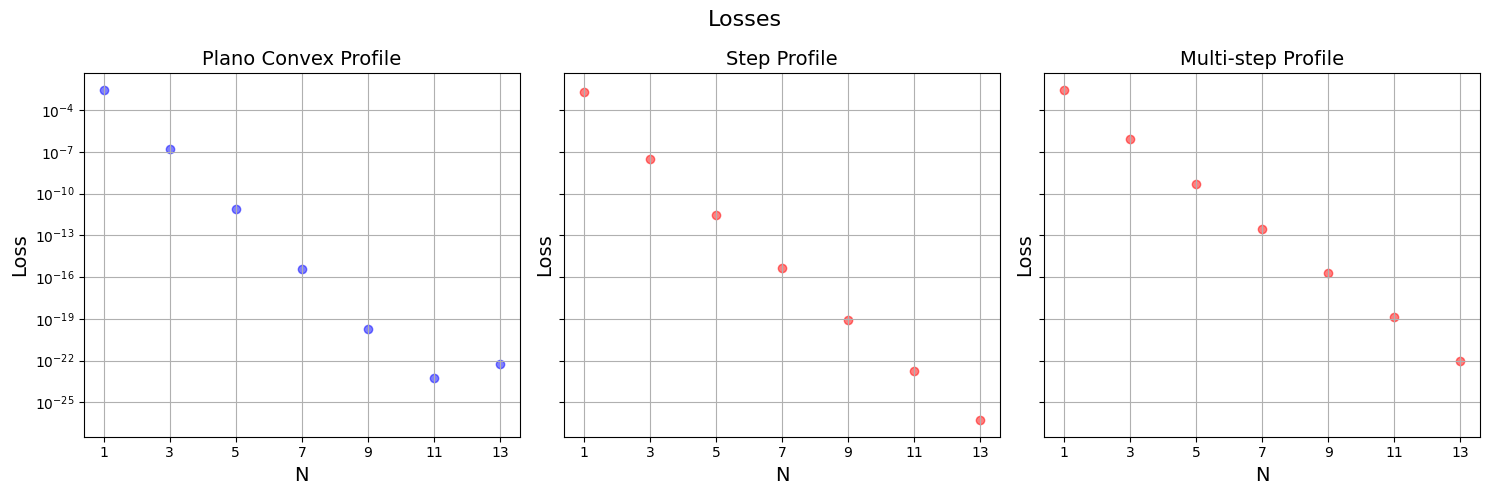

In [172]:
fig, axs = plt.subplots(1, 3, figsize=(15,5), sharey=True)
axs[0].scatter(results_pc["N"], results_pc["Loss"],marker='o', color='b', alpha=0.5)
#axs[0].plot(N_plot, Loss_fitter(N_plot, *popt_loss_pc), color='k', label='fit')

axs[1].scatter(results_step["N"], results_step["Loss"], marker='o', color='r', alpha=0.5)
#axs[1].plot(N_plot, Loss_fitter(N_plot, *popt_loss_step), color='k', label='fit')

axs[2].scatter(results_step["N"], results_ms["Loss"], marker='o', color='r', alpha=0.5)
#axs[2].plot(N_plot, Loss_fitter(N_plot, *popt_loss_ms), color='k', label='fit') 


axs[0].set_title('Plano Convex Profile', fontsize=14)
axs[1].set_title('Step Profile', fontsize=14)
axs[2].set_title('Multi-step Profile', fontsize=14)
for i in range(3):
    axs[i].set_xlabel('N', fontsize=14)
    axs[i].set_xticks(results_pc["N"])
    axs[i].set_ylabel(r"Loss", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].grid()

fig.suptitle('Losses', fontsize=16)
plt.tight_layout()

In [137]:
popt_hwhm_step, _ = curve_fit(Loss_fitter, results_step["N"], results_step["HWHM"], maxfev=10000) 
popt_hwhm_pc, _   = curve_fit(Loss_fitter, results_pc["N"], results_pc["HWHM"], maxfev=10000) 
popt_hwhm_ms, _   = curve_fit(Loss_fitter, results_ms["N"], results_ms["HWHM"], maxfev=10000)

In [138]:
density = 2.6*1e-3 #g/mm^3

In [139]:
def resonant_mass(hwhm):
    return np.array(hwhm)**2 * L0 * np.pi * density

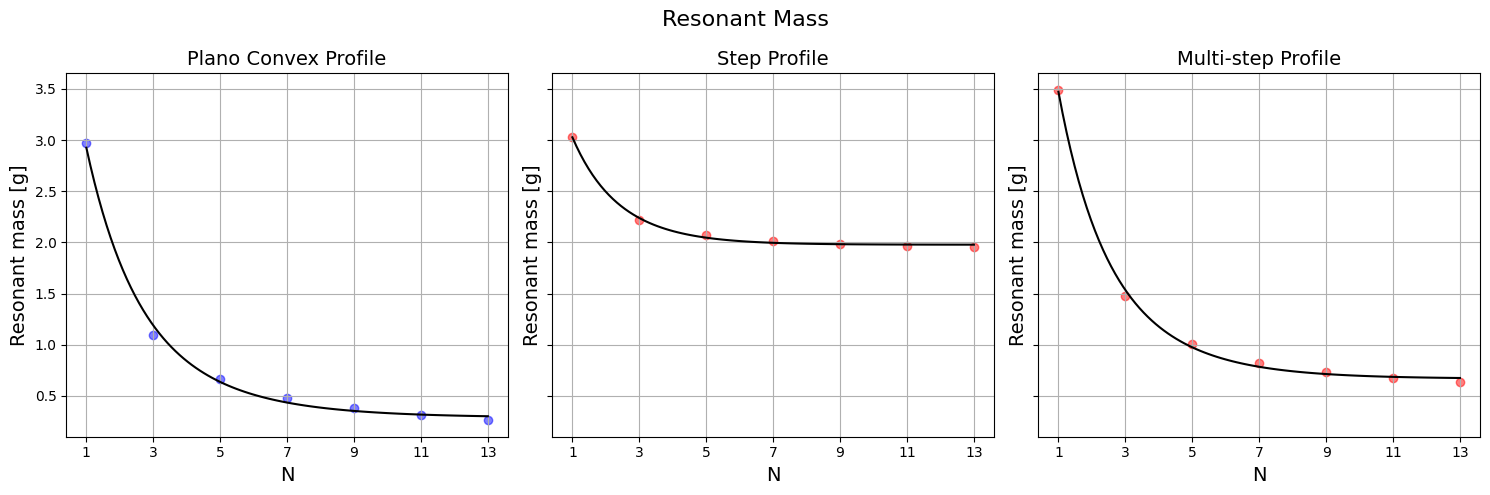

In [140]:
fig, axs = plt.subplots(1, 3, figsize=(15,5), sharey=True)
axs[0].scatter(results_pc["N"], resonant_mass(results_pc["HWHM"]), marker='o', color='b', alpha=0.5)
axs[0].plot(N_plot, resonant_mass(Loss_fitter(N_plot, *popt_hwhm_pc)), color='k', label='fit')

axs[1].scatter(results_step["N"], resonant_mass(results_step["HWHM"]), marker='o', color='r', alpha=0.5)
axs[1].plot(N_plot, resonant_mass(Loss_fitter(N_plot, *popt_hwhm_step)), color='k', label='fit')

axs[2].scatter(results_ms["N"], resonant_mass(results_ms["HWHM"]), marker='o', color='r', alpha=0.5)
axs[2].plot(N_plot, resonant_mass(Loss_fitter(N_plot, *popt_hwhm_ms)), color='k', label='fit')

for i in range(3):
    axs[i].set_xlabel('N', fontsize=14)
    axs[i].set_xticks(results_pc["N"])
    axs[i].set_ylabel(r"Resonant mass [g]", fontsize=14)
    axs[i].grid()

axs[0].set_title('Plano Convex Profile', fontsize=14)
axs[1].set_title('Step Profile', fontsize=14)
axs[2].set_title('Multi-step Profile', fontsize=14)
fig.suptitle('Resonant Mass', fontsize=16)
plt.tight_layout()